# Validation of our PV forecast pipeline

## Load Data from brazilian pv dataset

In [5]:
import pandas as pd
path = '../data/real_pv/br-pvgen/'
metadata_df = pd.read_csv(path + "metadata.csv")
metadata_df['ps_id'] = metadata_df['id']
metadata_df = metadata_df.set_index(['ps_id'])
measurements_df = pd.read_parquet(path + "merged.parquet")
measurements_df['datetime'] = pd.to_datetime(measurements_df['datetime'])
measurements_df = measurements_df.set_index(['datetime', 'ps_id'])
print(measurements_df.info())
measurements_df

<class 'pandas.DataFrame'>
MultiIndex: 752909 entries, (Timestamp('2024-03-26 17:15:00+0000', tz='UTC'), 'PS_001') to (Timestamp('2025-06-09 19:30:00+0000', tz='UTC'), 'PS_051')
Data columns (total 3 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   total_active_power_w         752909 non-null  float64
 1   ambient_temperature_celsius  752909 non-null  float64
 2   ghi_irradiance_wm2           752909 non-null  float64
dtypes: float64(3)
memory usage: 21.1+ MB
None


,,total_active_power_w,ambient_temperature_celsius,ghi_irradiance_wm2
datetime,ps_id,,,
2024-03-26 17:15:00+00:00,PS_001,4.055110e+05,23.000000,96.539849
2024-03-26 17:30:00+00:00,PS_001,8.395200e+04,22.960714,53.623824
2024-03-26 17:45:00+00:00,PS_001,1.457120e+05,21.767193,14.290886
2024-03-26 18:00:00+00:00,PS_001,2.090670e+05,20.596816,33.510205
2024-03-26 18:15:00+00:00,PS_001,2.729760e+05,20.431653,50.439045
...,...,...,...,...
2025-06-09 18:30:00+00:00,PS_051,2.235609e+06,34.851252,358.443756
2025-06-09 18:45:00+00:00,PS_051,2.072260e+06,34.802081,300.378761
2025-06-09 19:00:00+00:00,PS_051,1.732663e+06,34.334583,245.017496


## Helper Functions

In [6]:
import datetime

def filter_for_ps_id(df, ps_id):
    return df[df.index.get_level_values("ps_id") == ps_id]
    
def filter_for_date(df, year,month=None,day=None):
    
    filter_mask = (df.index.get_level_values("datetime").year == year)
    if month is not None:
        filter_mask = filter_mask & (df.index.get_level_values("datetime").month == month)
    if day is not None:
        filter_mask = filter_mask & (df.index.get_level_values("datetime").day == day)
    return df[filter_mask]

def calc_area_m2(df, ps_id):
    df = df.loc[ps_id]
    # using standard units
    g_stc = 1000 # W/m2
    nominal_power_w = df['nominal_power_mw'] * 1000000
    efficiency = df['panel_efficiency_percentage']/100
    return nominal_power_w/(g_stc*efficiency)

def get_bounding_rect_for_state(state):
    STATE_BOUNDS = {
        "SP": {
            "min_lat": -25.31,
            "max_lat": -19.78,
            "min_lon": -53.11,
            "max_lon": -44.16,
        },
        "RJ": {
            "min_lat": -23.37,
            "max_lat": -20.76,
            "min_lon": -44.89,
            "max_lon": -40.96,
        },
        "GO": {
            "min_lat": -19.50,
            "max_lat": -12.40,
            "min_lon": -53.25,
            "max_lon": -45.90,
        },
        "MG": {
            "min_lat": -22.92,
            "max_lat": -14.22,
            "min_lon": -51.05,
            "max_lon": -39.85,
        },
        "BA": {
            "min_lat": -18.35,
            "max_lat": -8.53,
            "min_lon": -46.62,
            "max_lon": -37.35,
        },
    }
    return STATE_BOUNDS[state]["min_lat"],STATE_BOUNDS[state]["max_lat"],STATE_BOUNDS[state]["min_lon"],STATE_BOUNDS[state]["max_lon"]

def get_bounding_rect_for_ps_id(df, ps_id):
    df = filter_for_ps_id(df, ps_id)
    return get_bounding_rect_for_state(df['brazil_federative_unit'].iloc[0])

print(calc_area_m2(metadata_df, 'PS_001'))
print(get_bounding_rect_for_ps_id(metadata_df, 'PS_001'))

measurements_df = filter_for_date(measurements_df, 2024)

24154.589371980677
(-25.31, -19.78, -53.11, -44.16)


## Test Visualization

<Axes: xlabel='datetime', ylabel='total_active_power_w'>

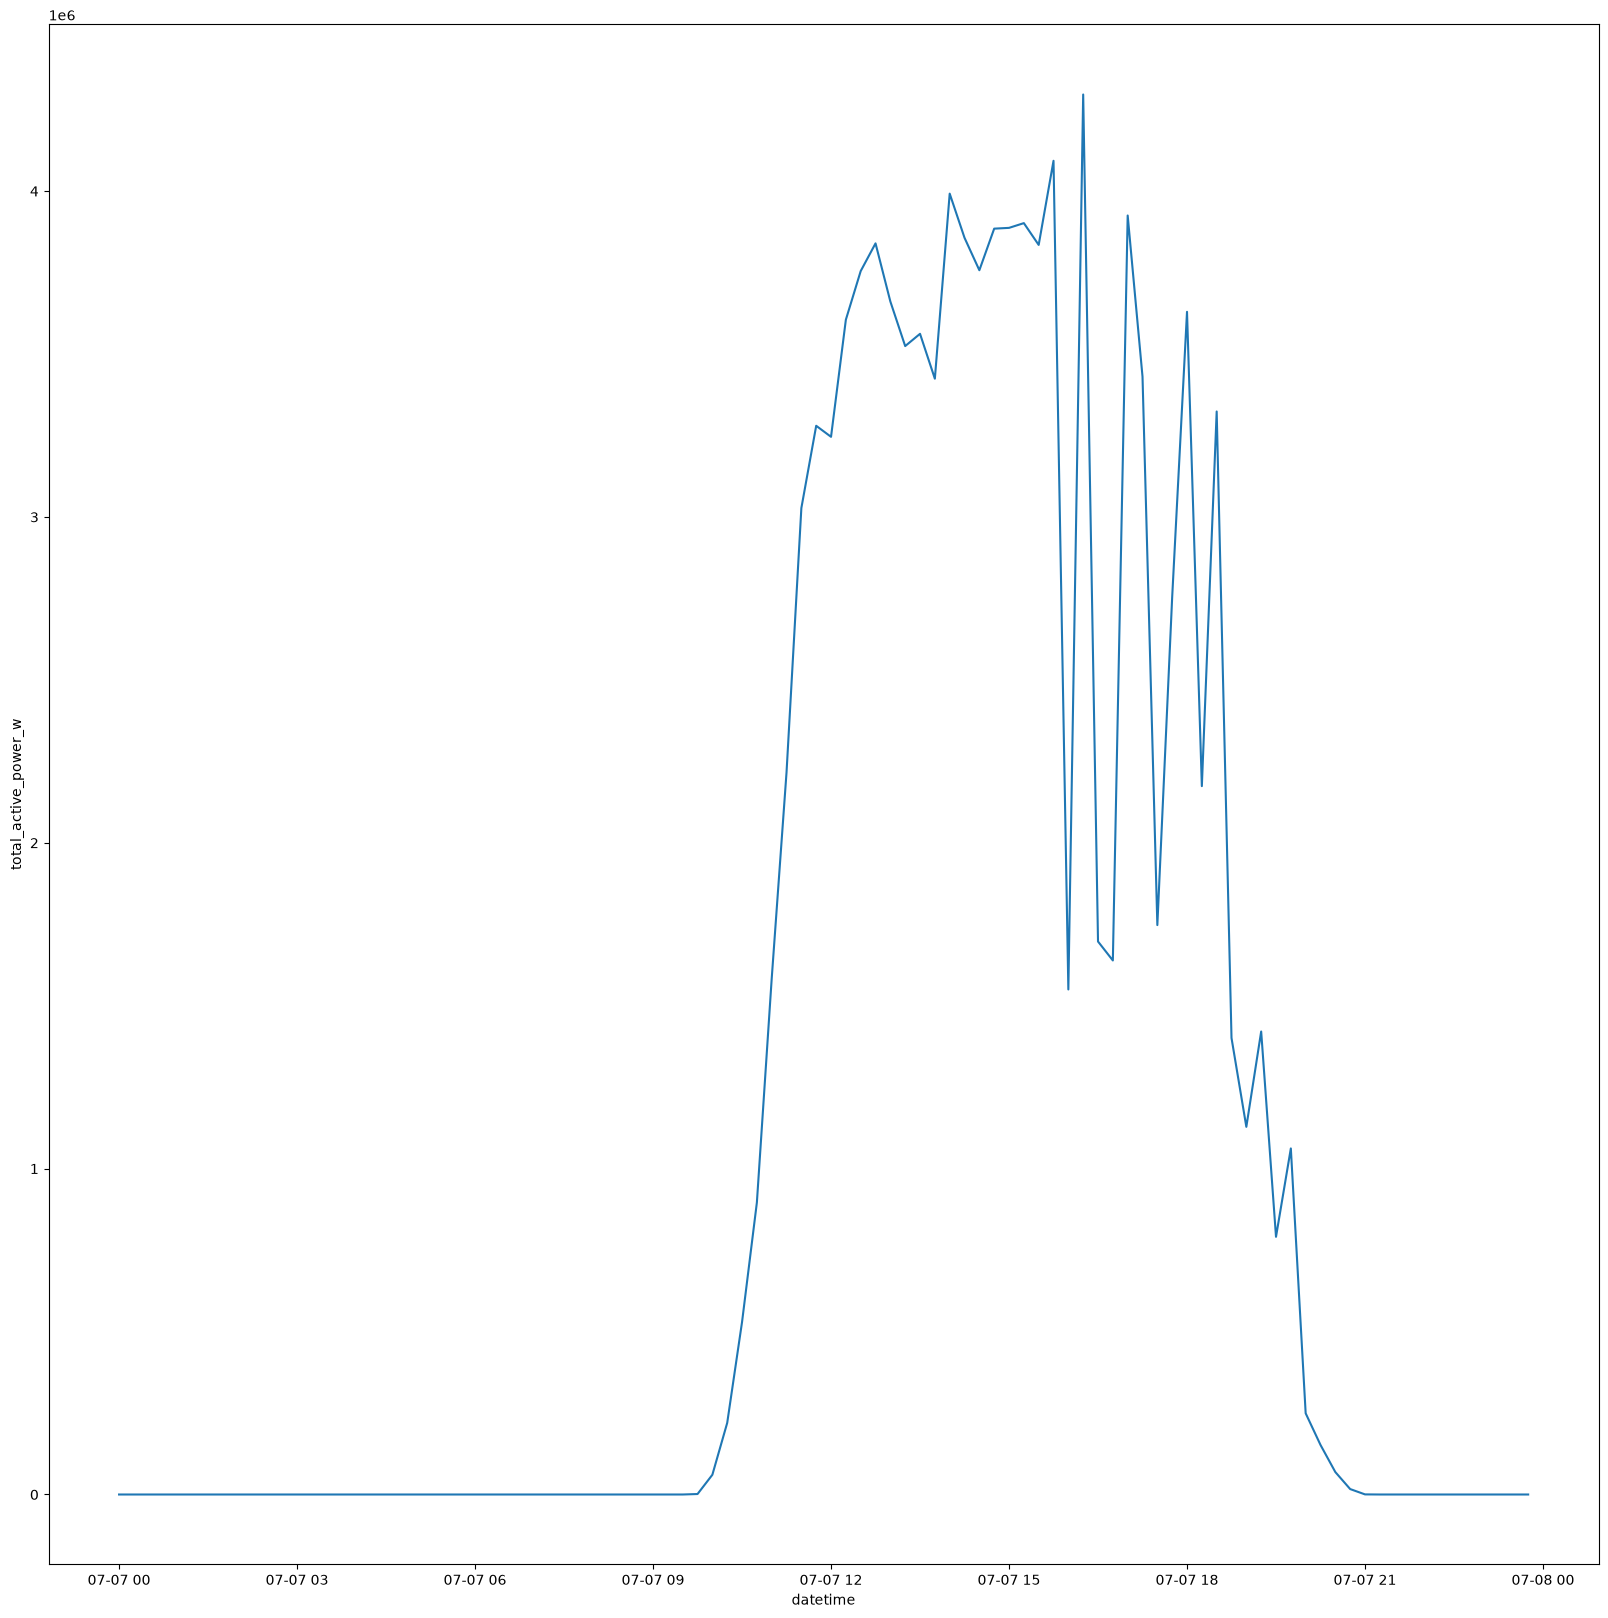

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(20,20))
sns.lineplot(filter_for_date(filter_for_ps_id(measurements_df, 'PS_001'), 2024,7,7), x="datetime", y="total_active_power_w")


## Preparing Validation
### Fetching Weather Data from API
#### Build clients and request

In [8]:
from app.weather.open_meteo import OpenMeteoProvider
from app.weather.adapters.default import DefaultWeatherAdapter
from app.weather.open_meteo_mapping import OPEN_METEO_VARIABLES
from app.weather.resolver import WeatherLocationResolver
from app.weather.request import WeatherForecastRequest
from app.weather.result import WeatherForecastResult
from app.forecasting.enums import ForecastMetric
from app.weather.providers.open_meteo.client import Client
from app.weather.location import WeatherLocation

from datetime import timezone, datetime, timedelta
api_url = "https://historical-forecast-api.open-meteo.com/v1/forecast"
provider = OpenMeteoProvider(Client(api_url))

resolver = WeatherLocationResolver(
        grid_size=0.1
    )

adapter = DefaultWeatherAdapter(OPEN_METEO_VARIABLES, resolver)

# mimicking WeatherService
def get_forecast(request: WeatherForecastRequest) -> WeatherForecastResult:
    provider_result = (
        provider.get_forecast(
            request
        )
    )
    return adapter.adapt(
        provider_result,
        request
    )

request_variables = [
        ForecastMetric.WIND_SPEED,
        ForecastMetric.CLOUD_COVER,
        ForecastMetric.TEMPERATURE,
        ForecastMetric.GLOBAL_SOLAR_IRRADIANCE,
        ForecastMetric.DIRECT_NORMAL_IRRADIANCE,
        ForecastMetric.DIFFUSE_IRRADIANCE
    ]





#### Testing request 

In [31]:
start_date = datetime.now(timezone.utc) - timedelta(seconds=365*24*60*60)

request = WeatherForecastRequest(
        start=start_date,
        end=start_date + timedelta(days=1),
        resolution=timedelta(minutes=15),
        locations=[WeatherLocation(52,10)],
        variables=request_variables
    )
print(get_forecast(request))

WeatherForecastResult(provider='open_meteo', model='best_match', forecasts=[WeatherLocationForecast(location=WeatherLocation(latitude=52.0, longitude=10.0), run=ForecastRun(start=datetime.datetime(2025, 8, 7, 0, 0, tzinfo=datetime.timezone.utc), resolution=datetime.timedelta(seconds=900), slots=97), series=[ForecastSeries(metric=<ForecastMetric.WIND_SPEED: 'wind_speed'>, values=[ForecastValue(p50=6.130578994750977, p05=None, p95=None, value_type=<ForecastValueType.FORECAST: 'forecast'>), ForecastValue(p50=6.130578994750977, p05=None, p95=None, value_type=<ForecastValueType.FORECAST: 'forecast'>), ForecastValue(p50=6.119999885559082, p05=None, p95=None, value_type=<ForecastValueType.FORECAST: 'forecast'>), ForecastValue(p50=6.130578994750977, p05=None, p95=None, value_type=<ForecastValueType.FORECAST: 'forecast'>), ForecastValue(p50=6.162207126617432, p05=None, p95=None, value_type=<ForecastValueType.FORECAST: 'forecast'>), ForecastValue(p50=6.162207126617432, p05=None, p95=None, value_

#### Adding forecast data: Actual request

In [9]:
import time
forecasts = {}

for ps_id in metadata_df.index:
    area = calc_area_m2(metadata_df, ps_id)
    # get forecast for whole grid in state
    min_lat, max_lat, min_lon, max_lon = get_bounding_rect_for_ps_id(metadata_df, ps_id)
    grid_count = 4
    locations = []
    filtered_measurement = filter_for_ps_id(measurements_df, ps_id)
    for i_lat in range(0, grid_count):
        lat = min_lat + i_lat*(max_lat - min_lat)/(grid_count - 1)
        for i_lon in range(0, grid_count):
            lon = min_lon + i_lon*(max_lon - min_lon)/(grid_count - 1)
            locations.append(WeatherLocation(lat,lon))
    start_date = filtered_measurement.index[0][0]
    end_date = filtered_measurement.index[len(filtered_measurement)-1][0]
    request = WeatherForecastRequest(
        start=start_date,
        end=end_date,
        resolution=timedelta(minutes=15),
        locations=locations,
        variables=request_variables
    )
    forecasts[ps_id] = get_forecast(request)
    time.sleep(3)


    
        
    

OpenMeteoRequestsError: failed to request 'https://historical-forecast-api.open-meteo.com/v1/forecast': {'error': True, 'reason': 'Minutely API request limit exceeded. Please try again in one minute.'}

#### Check samples of forecast results

In [10]:
print(forecasts['PS_001'].forecasts[0].location)
print(forecasts['PS_001'].forecasts[0].run)
print(forecasts['PS_001'].forecasts[0].series[0].values[0:20])
print(forecasts['PS_001'].forecasts[0].series[1].metric)
print(forecasts['PS_001'].forecasts[4].location)
print(forecasts['PS_001'].forecasts[5].location)


WeatherLocation(latitude=-25.3, longitude=-53.1)
ForecastRun(start=datetime.datetime(2024, 3, 26, 0, 0, tzinfo=datetime.timezone.utc), resolution=datetime.timedelta(seconds=900), slots=26907)
[ForecastValue(p50=5.116561412811279, p05=None, p95=None, value_type=<ForecastValueType.FORECAST: 'forecast'>), ForecastValue(p50=5.9834771156311035, p05=None, p95=None, value_type=<ForecastValueType.FORECAST: 'forecast'>), ForecastValue(p50=7.309418678283691, p05=None, p95=None, value_type=<ForecastValueType.FORECAST: 'forecast'>), ForecastValue(p50=8.686748504638672, p05=None, p95=None, value_type=<ForecastValueType.FORECAST: 'forecast'>), ForecastValue(p50=9.387651443481445, p05=None, p95=None, value_type=<ForecastValueType.FORECAST: 'forecast'>), ForecastValue(p50=9.387651443481445, p05=None, p95=None, value_type=<ForecastValueType.FORECAST: 'forecast'>), ForecastValue(p50=8.686748504638672, p05=None, p95=None, value_type=<ForecastValueType.FORECAST: 'forecast'>), ForecastValue(p50=7.956732749

#### Build dataframe from forecasts

In [11]:
df_rows = {}
locations = {}
for ps_id, forecast_result in forecasts.items():
    locations[ps_id] = {}
    for lid, forecast in enumerate(forecast_result.forecasts):
        start = forecast.run.start
        resolution = forecast.run.resolution
        locations[ps_id][lid] = forecast.location
        for sid, series in enumerate(forecast.series):
            column_name = series.metric + '_' + str(lid)
            time = start
            if column_name not in df_rows.keys():
                    df_rows[column_name] = {}
            for value in series.values:
                index = (time, ps_id)
                df_rows[column_name][index] = value.p50
                time += resolution
                
                

df = pd.DataFrame(df_rows)
df.index = df.index.set_names(["datetime", "ps_id"])
print(df['cloud_cover_0'])


                
        

datetime                   ps_id 
2024-03-26 00:00:00+00:00  PS_001     1.00
2024-03-26 00:15:00+00:00  PS_001     0.75
2024-03-26 00:30:00+00:00  PS_001     0.50
2024-03-26 00:45:00+00:00  PS_001     0.25
2024-03-26 01:00:00+00:00  PS_001     0.00
                                     ...  
2024-12-31 22:45:00+00:00  PS_009    24.00
2024-12-31 23:00:00+00:00  PS_009    13.00
2024-12-31 23:15:00+00:00  PS_009    13.00
2024-12-31 23:30:00+00:00  PS_009    13.00
2024-12-31 23:45:00+00:00  PS_009    13.00
Name: cloud_cover_0, Length: 217152, dtype: float64


#### Test structure and join

In [35]:
test_measurements_df = filter_for_ps_id(measurements_df, 'PS_001')
test_measurements_df = filter_for_ps_id(measurements_df, 'PS_001').join(df)
test_measurements_df


['datetime', 'ps_id']
['datetime', 'ps_id']


,,total_active_power_w,ambient_temperature_celsius,ghi_irradiance_wm2,wind_speed_0,temperature_0,global_solar_irradiance_0,direct_normal_irradiance_0,diffuse_irradiance_0,cloud_cover_0,wind_speed_1,...,global_solar_irradiance_23,direct_normal_irradiance_23,diffuse_irradiance_23,cloud_cover_23,wind_speed_24,temperature_24,global_solar_irradiance_24,direct_normal_irradiance_24,diffuse_irradiance_24,cloud_cover_24
datetime,ps_id,,,,,,,,,,,,,,,,,,,,,
2024-03-26 17:15:00+00:00,PS_001,4.055110e+05,23.000000,96.539849,3.826853,28.900000,773.0,817.755981,106.0,19.00,3.494968,...,266.0,14.897170,254.0,100.00,4.610250,21.400000,190.0,13.977434,179.0,100.00
2024-03-26 17:30:00+00:00,PS_001,8.395200e+04,22.960714,53.623824,3.457687,28.950001,744.0,811.314392,102.0,19.00,3.462369,...,251.0,15.507783,239.0,100.00,4.582052,21.450001,203.0,19.914339,188.0,100.00
2024-03-26 17:45:00+00:00,PS_001,1.457120e+05,21.767193,14.290886,3.462369,28.950001,714.0,806.813110,98.0,19.00,3.710795,...,233.0,14.890893,222.0,100.00,4.394360,21.500000,203.0,22.340818,187.0,100.00
2024-03-26 18:00:00+00:00,PS_001,2.090670e+05,20.596816,33.510205,3.415260,28.950001,684.0,804.279358,95.0,19.00,4.104631,...,212.0,12.850208,203.0,100.00,4.510787,21.500000,196.0,22.189575,181.0,100.00
2024-03-26 18:15:00+00:00,PS_001,2.729760e+05,20.431653,50.439045,3.640275,28.900000,651.0,799.489990,93.0,19.25,4.510787,...,189.0,10.622431,182.0,100.00,4.829907,21.500000,183.0,18.961905,171.0,100.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-09 18:15:00+00:00,PS_001,3.581014e+06,21.800001,520.581228,12.033103,16.700001,432.0,721.416199,85.0,8.50,4.353619,...,371.0,621.093628,77.0,64.25,14.256409,24.150000,340.0,559.441833,89.0,29.25
2025-06-09 18:30:00+00:00,PS_001,1.702499e+06,22.500000,268.839993,12.096214,16.700001,400.0,727.392273,76.0,6.00,3.852168,...,320.0,570.011047,74.0,72.50,13.605190,24.100000,303.0,537.731995,85.0,20.50
2025-06-09 18:45:00+00:00,PS_001,1.473602e+06,22.175001,177.866251,11.919479,16.650000,362.0,719.490112,69.0,3.50,3.438895,...,276.0,531.796753,70.0,80.75,13.040997,24.000000,266.0,525.219543,77.0,11.75


#### Find out locations via correlations of weather variables

In [14]:
import numpy as np

irradiance_corr = {}
temperature_corr = {}
best_locations = {}
best_loc_indices = {}
for ps_id in forecasts.keys():
    test_locations = locations[ps_id]
    test_measurements_df = filter_for_ps_id(measurements_df, ps_id).join(df)
    
    irradiance_col_names = ['ghi_irradiance_wm2']
    temperature_col_names = ['ambient_temperature_celsius']
    for lid, location in enumerate(test_locations):
        irradiance_col_names.append('global_solar_irradiance_' + str(lid))
        temperature_col_names.append('temperature_' + str(lid))
    test_irradiance_df = test_measurements_df[irradiance_col_names]
    test_temperature_df = test_measurements_df[temperature_col_names]
    
    irradiance_corr[ps_id] = test_irradiance_df.corr()
    temperature_corr[ps_id] = test_temperature_df.corr()
    # avoid finding out correlation with same column is highest ;) 
    irradiance_corr[ps_id].loc['ghi_irradiance_wm2', 'ghi_irradiance_wm2'] = 0
    temperature_corr[ps_id].loc['ambient_temperature_celsius', 'ambient_temperature_celsius'] = 0
    #display(irradiance_corr[ps_id])
    #print(irradiance_corr[ps_id]['ghi_irradiance_wm2'].idxmax())
    #display(temperature_corr[ps_id])
    #print(temperature_corr[ps_id]['ambient_temperature_celsius'].idxmax())
    best_index = str(irradiance_corr[ps_id]['ghi_irradiance_wm2'].idxmax()).split('_')[-1]
    best_loc_indices[ps_id] = best_index
    best_locations[ps_id] = test_locations[int(best_index)]

print("Best locations", best_locations)

Best locations {'PS_001': WeatherLocation(latitude=-21.6, longitude=-47.2), 'PS_002': WeatherLocation(latitude=-22.5, longitude=-43.6), 'PS_003': WeatherLocation(latitude=-22.5, longitude=-43.6), 'PS_004': WeatherLocation(latitude=-23.400000000000002, longitude=-47.1), 'PS_005': WeatherLocation(latitude=-17.1, longitude=-48.300000000000004), 'PS_006': WeatherLocation(latitude=-22.900000000000002, longitude=-47.300000000000004), 'PS_007': WeatherLocation(latitude=-22.5, longitude=-43.6), 'PS_008': WeatherLocation(latitude=-21.6, longitude=-50.1), 'PS_009': WeatherLocation(latitude=-21.6, longitude=-50.1)}


#### Creating PvForecast Calculator

In [13]:
from app.asset_forecast.calculators.pv_power_calculator import (
    PvPowerCalculator,
)

from app.asset_forecast.calculators.plane_of_array_calculator import (
    PlaneOfArrayCalculator,
)

from app.asset_forecast.calculators.solar_geometry_calculator import (
    SolarGeometryCalculator,
)
from app.asset_forecast.calculators.pv_forecast_calculator import (
    PvForecastCalculator,
)

calculator = PvForecastCalculator(
        solar_geometry_calculator=(
            SolarGeometryCalculator()
        ),
        plane_of_array_calculator=(
            PlaneOfArrayCalculator()
        ),
        pv_power_calculator=(
            PvPowerCalculator()
        ),
    )

#### Generating forecast

In [21]:
from app.asset_forecast.domain.pv_forecast import (
    PvForecastInput,
    PvForecastResult,
)

from app.asset_forecast.domain.panel_geometry import PanelGeometry
from app.asset_forecast.domain.pv_configuration import PvConfiguration

forecast_rows = {
    'calculated_poa_radiance': {},
    'calculated_active_power_w': {}
}
measurements_df = measurements_df.join(df) 
for ps_id in forecasts.keys():
    test_measurements_df = filter_for_ps_id(measurements_df, ps_id)
    location = best_locations[ps_id]
    # To find the corresponding column
    loc_index = best_loc_indices[ps_id]
    area = calc_area_m2(metadata_df, ps_id)
    efficiency = metadata_df.loc[ps_id]['panel_efficiency_percentage']/100
    # best guess: pointing to sun over equator
    tilt = abs(location.latitude)
    # best guess: pointing north on sothern hemisphere
    azimuth = 0
    direct_irradiance_colname = 'direct_normal_irradiance_' + loc_index
    diffuse_colname = 'diffuse_irradiance_' + loc_index
    panel_geometry = PanelGeometry(tilt,azimuth)
    pv_configuration = PvConfiguration(area,efficiency)
    for index, row in test_measurements_df.iterrows():
        forecast_input = PvForecastInput(
            timestamp=index[0],
            latitude=location.latitude,
            longitude=location.longitude,
            direct_normal_irradiance=row[direct_irradiance_colname],
            diffuse_radiation=row[diffuse_colname],
            panel_geometry=panel_geometry,
            pv_configuration=pv_configuration
        )
        forecast_result = calculator.calculate(forecast_input)
        forecast_rows['calculated_poa_radiance'][index] = forecast_result.plane_of_array_irradiance
        forecast_rows['calculated_active_power_w'][index] = forecast_result.active_power_kw * 1000

forecast_df = pd.DataFrame(forecast_rows)

    
    

In [23]:
forecast_df.index = forecast_df.index.set_names(['datetime', 'ps_id'])

measurements_df = measurements_df.join(forecast_df)


/tmp/ipykernel_3598603/3875203249.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


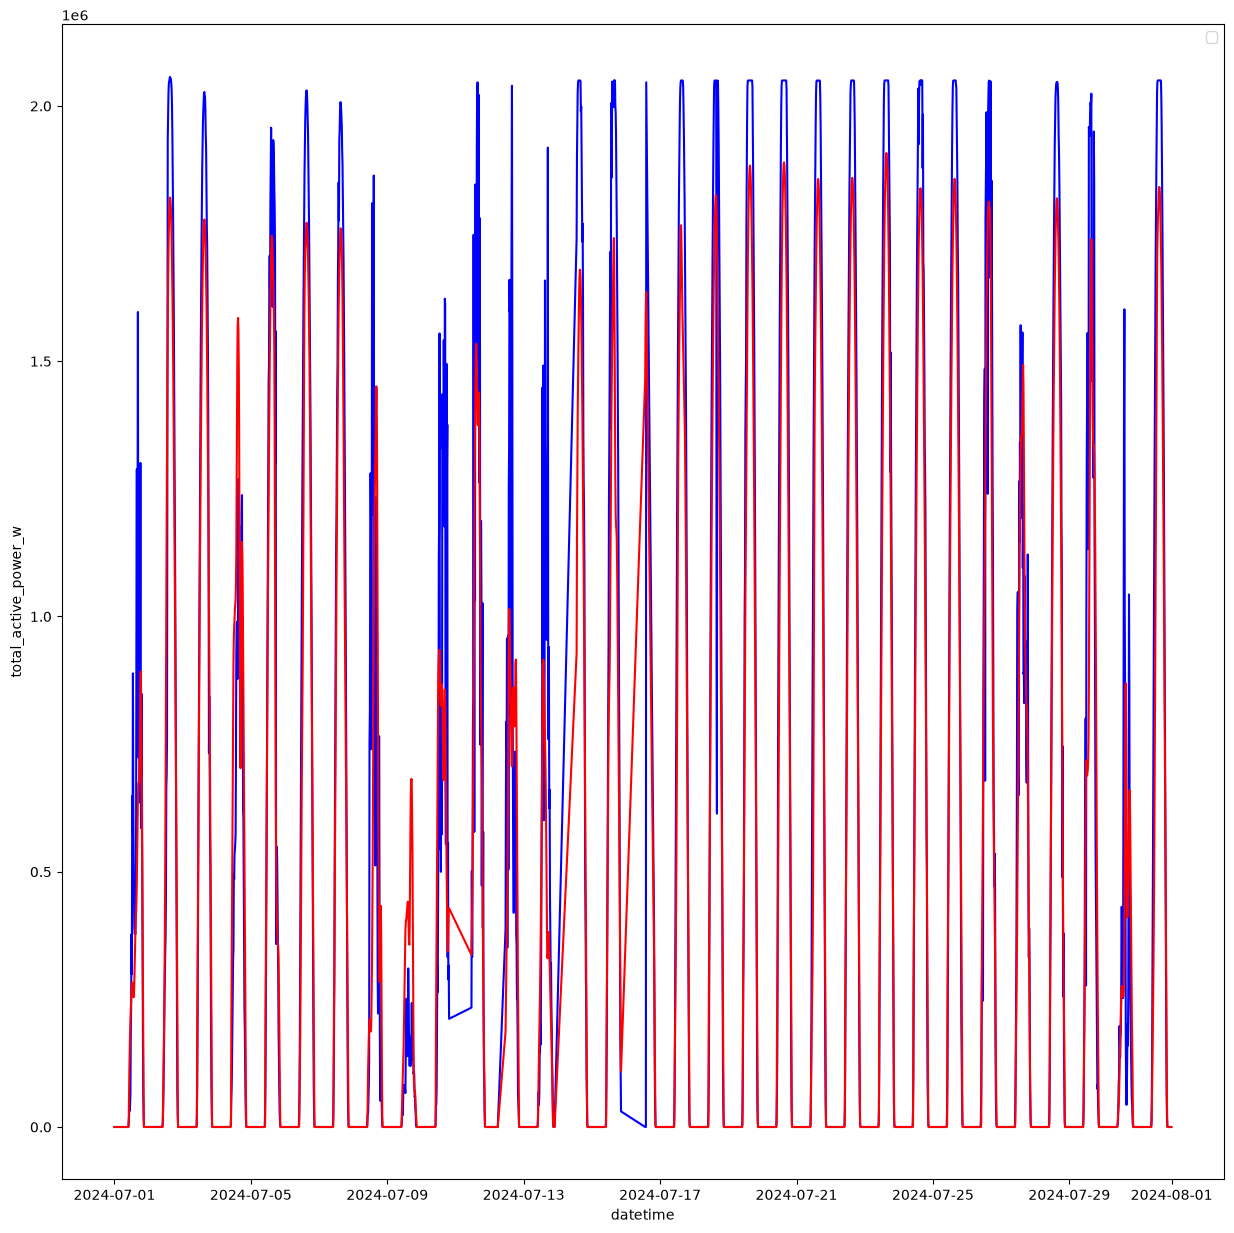

In [35]:
plt.figure(figsize=(15,15))
sns.lineplot(filter_for_date(filter_for_ps_id(measurements_df, 'PS_004'), 2024,7), x="datetime", y="total_active_power_w", color="b")
sns.lineplot(filter_for_date(filter_for_ps_id(measurements_df, 'PS_004'), 2024,7), x="datetime", y="calculated_active_power_w", color="r")
plt.legend()
#plt.figure(figsize=(15,15))
#sns.lineplot(filter_for_date(filter_for_ps_id(measurements_df, 'PS_001'), 2024,7), x="datetime", y=["total_active_power_w", "calculated_poa_radiance"])

### First Result

We can see that our forecast is in realistic dimensions. There are some systematic effects that can be used for improvement: Rainy/Cloudy days are systematically over-predicted. We need to adjust our diffuse radiation model. Tracker/Fixed systems are counter-intuitively predicted: We overrate trackers (PS_001, PS_005) (while not assuming their better alignment with the sun in the prediction) and underrated fixed (PS_002 - PS_004) systems. Also, we know these systems are bifacial, which is not reflected in our model yet. 